# 06 — Die Entscheidungsregel

**Ziel dieses Notebooks** ist ein begründeter Schwellenwert statt der
Voreinstellung 0,5.

`predict()` setzt diese Grenze stillschweigend auf 0,5 — ein Wert, der nur dann richtig wäre, wenn beide Fehlerarten gleich viel kosten und beide Klassen gleich häufig sind.

Gesucht wird auf der **Validierungsmenge**. Die Testmenge bleibt unangetastet.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score

from src.data.split import lade_teilmengen, trenne_merkmale_und_ziel
from src.data.validate import load_params
from src.features.build_features import baue_pipeline
from src.modeling.threshold import finde_beste_schwelle, kosten_je_schwelle
from src.utils.plotting import FARBEN, nur_y_gitter, setze_stil, speichere

import matplotlib.pyplot as plt

setze_stil()
params = load_params()
kosten = params["costs"]

train, val, _ = lade_teilmengen()
X_train, y_train = trenne_merkmale_und_ziel(train, params)
X_val, y_val = trenne_merkmale_und_ziel(val, params)

modell = baue_pipeline(
    RandomForestClassifier(random_state=params["seed"], n_jobs=-1,
                           **params["model"]["random_forest"])
)
modell.fit(X_train, y_train)
wahrscheinlichkeit = modell.predict_proba(X_val)[:, 1]

print(f"Modell: Random Forest, {params['model']['random_forest']['n_estimators']} Bäume")
print(f"PR-AUC auf der Validierungsmenge: "
      f"{average_precision_score(y_val, wahrscheinlichkeit):.3f}")

Modell: Random Forest, 150 Bäume
PR-AUC auf der Validierungsmenge: 0.860


## 1 Verteilung den Wahrscheinlichkeiten

In [2]:
print("Verteilung der geschätzten Ausfallwahrscheinlichkeit:")
print(pd.Series(wahrscheinlichkeit).describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]).round(3).to_string())
print()
print(f"Anteil über 0,50: {(wahrscheinlichkeit >= 0.5).mean():.2%}")
print(f"Anteil über 0,06: {(wahrscheinlichkeit >= 0.06).mean():.2%}")

Verteilung der geschätzten Ausfallwahrscheinlichkeit:
count    1500.000
mean        0.031
std         0.148
min         0.000
50%         0.000
90%         0.020
95%         0.079
99%         0.959
max         0.995

Anteil über 0,50: 2.53%
Anteil über 0,06: 5.73%


Über 0,50 liegen nur knapp 2 % aller Fälle — das Modell schweigt also fast
immer. Bei 3,4 % Ausfallrate *sollen* die meisten Wahrscheinlichkeiten niedrig sein. 

## 2 Kostenkurve

Für jeden Schwellenwert von 0,01 bis 0,99 wird die Verwechslungsmatrix gebildet
und in Euro übersetzt:

```
Kosten = FN × 10.000 €  +  FP × 500 €  +  TP × 800 €
```

In [3]:
kurve = kosten_je_schwelle(y_val, wahrscheinlichkeit, kosten)
beste = finde_beste_schwelle(kurve)

for schluessel, wert in beste.items():
    print(f"{schluessel:26s} {wert}")

schwelle                   0.060000000000000005
kosten_eur                 126200.0
recall                     0.8627450980392157
precision                  0.5116279069767442
tp                         44
fp                         42
fn                         7
gleichwertige_kandidaten   1


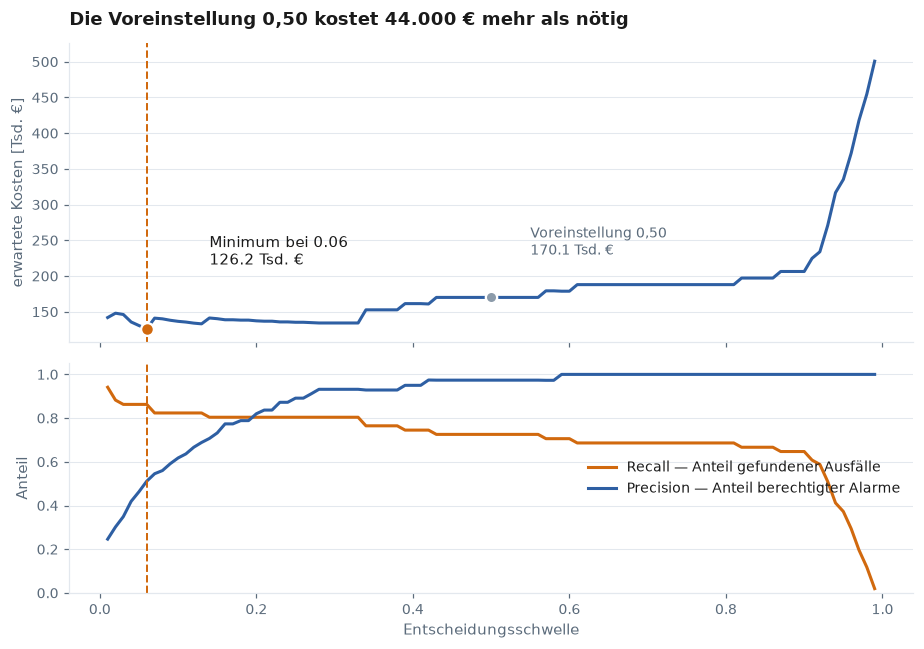

In [4]:
fig, (oben, unten) = plt.subplots(2, 1, figsize=(8.5, 6), sharex=True,
                                  gridspec_kw={"height_ratios": [1.3, 1]})

# ── Kosten ─────────────────────────────────────────────────────────────
oben.plot(kurve["Schwelle"], kurve["Kosten EUR"] / 1000,
          color=FARBEN["kein_ausfall"], linewidth=2)
oben.axvline(beste["schwelle"], color=FARBEN["ausfall"], linestyle="--", linewidth=1.3)
oben.scatter([beste["schwelle"]], [beste["kosten_eur"] / 1000],
             s=70, color=FARBEN["ausfall"], zorder=5,
             edgecolors="white", linewidths=1.5)
oben.annotate(f"Minimum bei {beste['schwelle']:.2f}\n{beste['kosten_eur'] / 1000:.1f} Tsd. €",
              xy=(beste["schwelle"], beste["kosten_eur"] / 1000),
              xytext=(beste["schwelle"] + 0.08, beste["kosten_eur"] / 1000 + 90),
              fontsize=9.5, color=FARBEN["text"])

bei_05 = kurve.iloc[(kurve["Schwelle"] - 0.5).abs().argmin()]
oben.scatter([0.5], [bei_05["Kosten EUR"] / 1000], s=55,
             color=FARBEN["neutral"], zorder=5, edgecolors="white", linewidths=1.5)
oben.annotate(f"Voreinstellung 0,50\n{bei_05['Kosten EUR'] / 1000:.1f} Tsd. €",
              xy=(0.5, bei_05["Kosten EUR"] / 1000),
              xytext=(0.55, bei_05["Kosten EUR"] / 1000 + 60),
              fontsize=9, color=FARBEN["text_sekundaer"])

oben.set_ylim(kurve["Kosten EUR"].min() / 1000 - 18,
              kurve["Kosten EUR"].max() / 1000 + 25)
oben.set_ylabel("erwartete Kosten [Tsd. €]")
oben.set_title("Die Voreinstellung 0,50 kostet 44.000 € mehr als nötig", loc="left")
nur_y_gitter(oben)

# ── Recall und Precision ───────────────────────────────────────────────
unten.plot(kurve["Schwelle"], kurve["Recall"], color=FARBEN["ausfall"],
           linewidth=2, label="Recall — Anteil gefundener Ausfälle")
unten.plot(kurve["Schwelle"], kurve["Precision"], color=FARBEN["kein_ausfall"],
           linewidth=2, label="Precision — Anteil berechtigter Alarme")
unten.axvline(beste["schwelle"], color=FARBEN["ausfall"], linestyle="--", linewidth=1.3)

unten.set_xlabel("Entscheidungsschwelle")
unten.set_ylabel("Anteil")
unten.set_ylim(0, 1.05)
unten.legend(loc="center right")
nur_y_gitter(unten)

fig.tight_layout()
speichere(fig, "14_kostenkurve")
plt.show()

Die Kurve hat ein **breites Tal zwischen etwa 0,04 und 0,30** — in diesem
Bereich liegen die Kosten zwischen 126.200 € und 141.300 €, also innerhalb von
rund zwölf Prozent. Oberhalb von 0,30 steigt sie dann deutlich an, weil das
Modell anfängt, echte Ausfälle zu übersehen, und jeder davon 10.000 € kostet.

In der Validierungsmenge liegen nur 51 Ausfälle. Ein einziger davon entspricht 10.000 € und damit rund acht Prozent der Gesamtkosten. Die genaue Lage des Minimums bei 0,06 ist nicht belastbar — belastbar ist die Aussage, dass der Wert **deutlich unter 0,3** liegen muss. Innerhalb des Tals ist die Wahl weitgehend beliebig.

Links des Tals steigen die Kosten langsam, weil Fehlalarme nur 500 € kosten.
Rechts davon steigen sie schnell.

Die untere Kurve zeigt, womit das erkauft wird. Am gewählten Punkt liegt der
Recall bei 0,863 — das Modell findet knapp neun von zehn Ausfällen. Die
Precision liegt bei 0,512, also ist etwa jeder zweite Alarm ein Fehlalarm. Neunzehn Fehlalarme sind billiger als ein übersehener Ausfall.

## 3 Vergleich in Zahlen

In [5]:
auswahl = kurve[kurve["Schwelle"].round(2).isin(
    [0.03, round(beste["schwelle"], 2), 0.10, 0.25, 0.30, 0.50]
)]
nichts_tun = int(y_val.sum()) * kosten["false_negative_eur"]

tabelle = auswahl.set_index("Schwelle")[
    ["TP", "FP", "FN", "Recall", "Precision", "Kosten EUR"]
].copy()
tabelle["Ersparnis gegenüber Nichtstun"] = nichts_tun - tabelle["Kosten EUR"]
tabelle.round(3)

,TP,FP,FN,Recall,Precision,Kosten EUR,Ersparnis gegenüber Nichtstun
Schwelle,,,,,,,
0.03,44,82,7,0.863,0.349,146200.0,363800.0
0.06,44,42,7,0.863,0.512,126200.0,383800.0
0.10,42,26,9,0.824,0.618,136600.0,373400.0
0.25,41,5,10,0.804,0.891,135300.0,374700.0
0.30,41,3,10,0.804,0.932,134300.0,375700.0
0.50,37,1,14,0.725,0.974,170100.0,339900.0


Der Unterschied zwischen 0,06 und 0,50 ist nicht akademisch: **43.900 €** auf
1.500 geprüfte Betriebszustände. Hochgerechnet auf den vollen Datensatz wären
das rund 290.000 €.

Keine Modellverbesserung — dasselbe Modell, dieselben Gewichte, nur eine andere Zahl.

## 4 Schwellenwert gehört zum Modell

Der Wert steht jetzt in `params.yaml`:

```yaml
decision:
  threshold: 0.06
```

In [6]:
print("Eintrag in params.yaml:")
print(f"  decision.threshold = {params['decision']['threshold']}")
print()
# Rechnerische Untergrenze aus den Kostensätzen, zum Vergleich.
rechnerisch = kosten["false_positive_eur"] / (
    kosten["false_negative_eur"] - kosten["true_positive_eur"] + kosten["false_positive_eur"]
)
print(f"Rechnerisch lohnender Alarm ab: {rechnerisch:.3f}")
print(f"Gemessenes Kostenminimum bei  : {beste['schwelle']:.3f}")

Eintrag in params.yaml:
  decision.threshold = 0.06

Rechnerisch lohnender Alarm ab: 0.052
Gemessenes Kostenminimum bei  : 0.060


Die beiden Werte liegen nah beieinander — 0,052 aus der reinen Kostenrechnung,
0,06 aus der Messung.

---

## Summary

| | Schwelle 0,50 | Schwelle 0,06 |
|---|---|---|
| gefundene Ausfälle | 37 von 51 | **44 von 51** |
| übersehene Ausfälle | 14 | **7** |
| Fehlalarme | 1 | 42 |
| Recall | 0,725 | **0,863** |
| Precision | 0,974 | 0,512 |
| Kosten | 170.100 € | **126.200 €** |

Der Schwellenwert wurde auf der Validierungsmenge gesucht, nicht auf der Testmenge. Die Kostenkurve hat ein breites Tal und bei nur 51 Ausfällen ist die genaue Lage des Minimums nicht belastbar — belastbar ist „deutlich unter 0,3". Ein zu niedriger Wert ist dabei ungefährlicher als ein zu hoher. Die gemessene Schwelle von 0,06 liegt nah an der aus den Kostensätzen berechneten von 0,052.